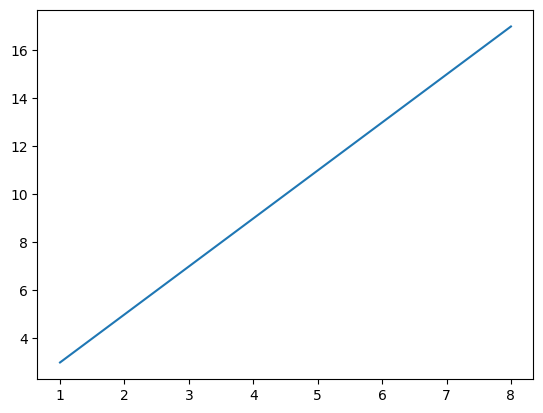

In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[1.0],[2.0],[3.0],[4.0],[5.0],[6.0],[7.0],[8.0]], dtype='float')
y = np.array([[3.0],[5.0],[7.0],[9.0],[11.0],[13.0],[15.0],[17.0]], dtype='float')

plt.plot(X,y)

In [2]:
# Initialize Model
model =  LinearRegression()
model.fit(X, y)

test_array = np.array([[9.0],[10.0],[11.0]], dtype='float')

model.predict(test_array)

model.coef_, model.intercept_


(array([[2.]]), array([1.]))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

In [4]:
X,y= fetch_california_housing(return_X_y=True)
type(X),type(y)
X.shape, y.shape

((20640, 8), (20640,))

In [ ]:
#Function to reterive data from data path 
import urllib.request 

data_path = 'https://raw.githubusercontent.com/nyandwi/public_datasets/master/housing.csv'

def download_read_data(path):
    ## Only retrieve the directory of the data

    data_path =  urllib.request.urlretrieve(path)[0]
    data = pd.read_csv(path)
    
    return data

In [6]:
cal_data = download_read_data(data_path)

In [7]:
cal_data.head()
cal_data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [8]:
cal_data.info()
len(cal_data.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


10

In [9]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(cal_data, test_size=0.1, random_state=42)


In [10]:
print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))


The size of training data is: 18576 
The size of testing data is: 2064


In [11]:
#copy training data 
cal_train = train_data.copy()

In [12]:
train_data.describe(include='all')
train_data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,18576.0,NaN,NaN,NaN,-119.575033,2.00384,-124.35,-121.8,-118.5,-118.01,-114.31
latitude,18576.0,NaN,NaN,NaN,35.636918,2.135052,32.55,33.93,34.26,37.72,41.95
housing_median_age,18576.0,NaN,NaN,NaN,28.611488,12.596526,1.0,18.0,29.0,37.0,52.0
total_rooms,18576.0,NaN,NaN,NaN,2637.706126,2181.859884,2.0,1450.75,2127.0,3150.5,39320.0
total_bedrooms,18576.0,NaN,NaN,NaN,537.863211,419.157368,1.0,296.0,436.0,647.0,6445.0
population,18576.0,NaN,NaN,NaN,1427.055879,1139.915138,3.0,787.0,1167.0,1726.0,35682.0
households,18576.0,NaN,NaN,NaN,499.649763,381.686386,1.0,280.0,410.0,605.0,6082.0
median_income,18576.0,NaN,NaN,NaN,3.872836,1.891866,0.4999,2.5643,3.5433,4.7569,15.0001
median_house_value,18576.0,NaN,NaN,NaN,206861.739233,115386.011008,14999.0,119700.0,179650.0,264900.0,500001.0
ocean_proximity,18576,5,<1H OCEAN,8221,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#check missing values 
train_data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [14]:
print('The Percentage of missing values in total_bedrooms is: {}%'.format(train_data.isnull().sum()['total_bedrooms'] / len(train_data) * 100))

The Percentage of missing values in total_bedrooms is: 0.0%


In [15]:
train_data['ocean_proximity'].value_counts

<bound method IndexOpsMixin.value_counts of 5564     <1H OCEAN
16016     NEAR BAY
17131     NEAR BAY
11752       INLAND
2308        INLAND
           ...    
11284    <1H OCEAN
11964       INLAND
5390     <1H OCEAN
860      <1H OCEAN
15795     NEAR BAY
Name: ocean_proximity, Length: 18576, dtype: object>

<Axes: xlabel='ocean_proximity', ylabel='count'>

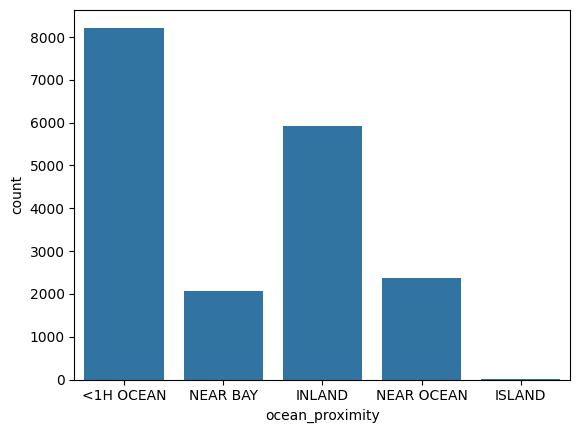

In [16]:
sns.countplot(train_data,x='ocean_proximity')

__Correlation__ is a statistical measure that quantifies the strength and direction of the linear relationship between two variables.

This measure is represented by the correlation coefficient, which can range from -1 to 1.

A value of 1 indicates a perfect positive correlation, meaning that as one variable increases, the other variable also increases proportionally.

A value of -1 indicates a perfect negative correlation, meaning that as one variable increases, the other variable decreases proportionally.

A value of 0 indicates no linear correlation, meaning that there is no predictable linear relationship between the changes in the two variables

In [17]:
correlation = train_data.corr(numeric_only=True)
correlation['median_house_value']


longitude            -0.047552
latitude             -0.142503
housing_median_age    0.105493
total_rooms           0.135327
total_bedrooms        0.050577
population           -0.023859
households            0.065760
median_income         0.689782
median_house_value    1.000000
Name: median_house_value, dtype: float64

<Axes: >

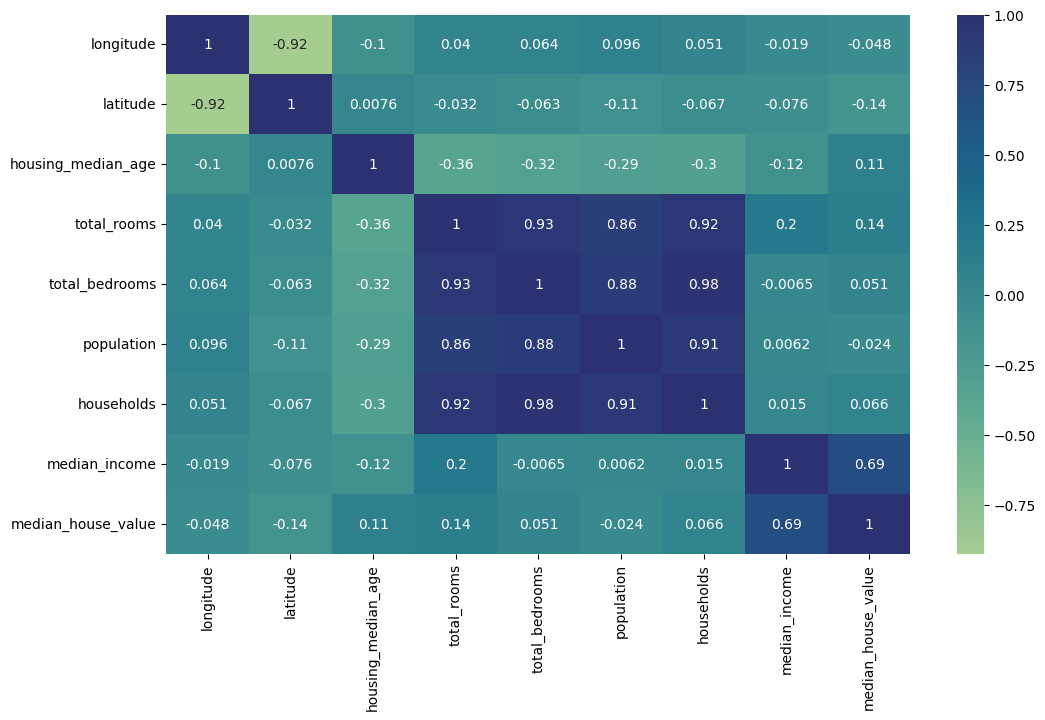

In [18]:
#### Visualizing correlation

plt.figure(figsize=(12,7))

sns.heatmap(correlation,annot=True,cmap='crest')

Image of California -

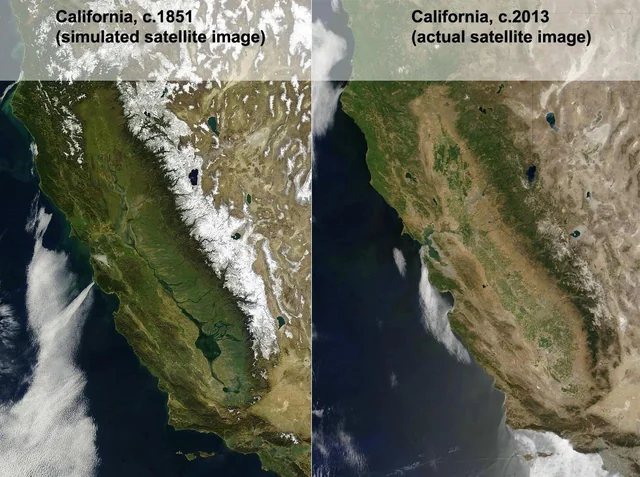

<Axes: xlabel='longitude', ylabel='latitude'>

<Figure size 1200x700 with 0 Axes>

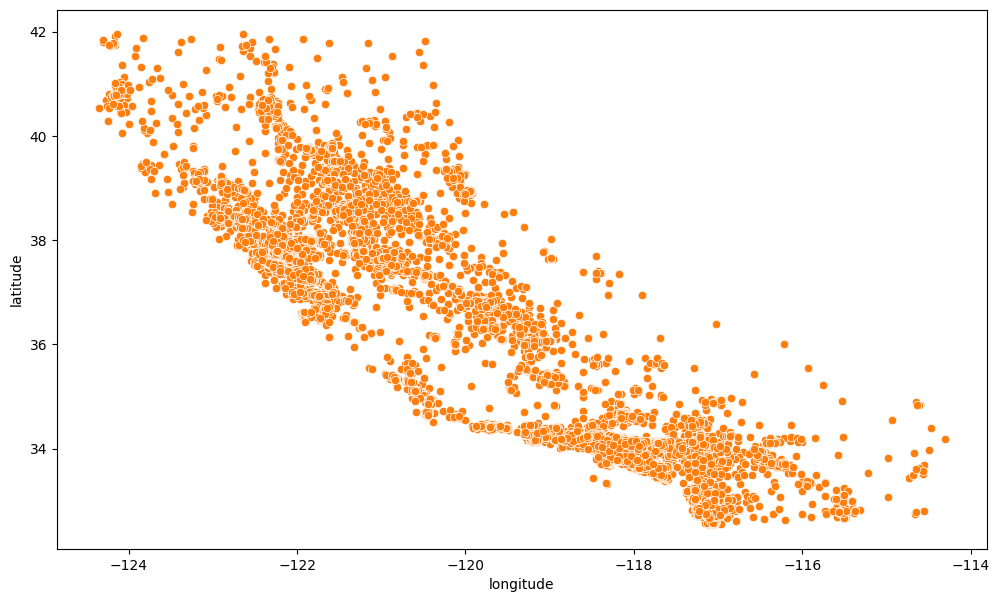

In [19]:
plt.figure(figsize=(12,7))

plt.figure(figsize=(12,7))

sns.scatterplot(data = train_data, x='longitude', y='latitude')
sns.scatterplot(data = train_data, x='longitude', y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

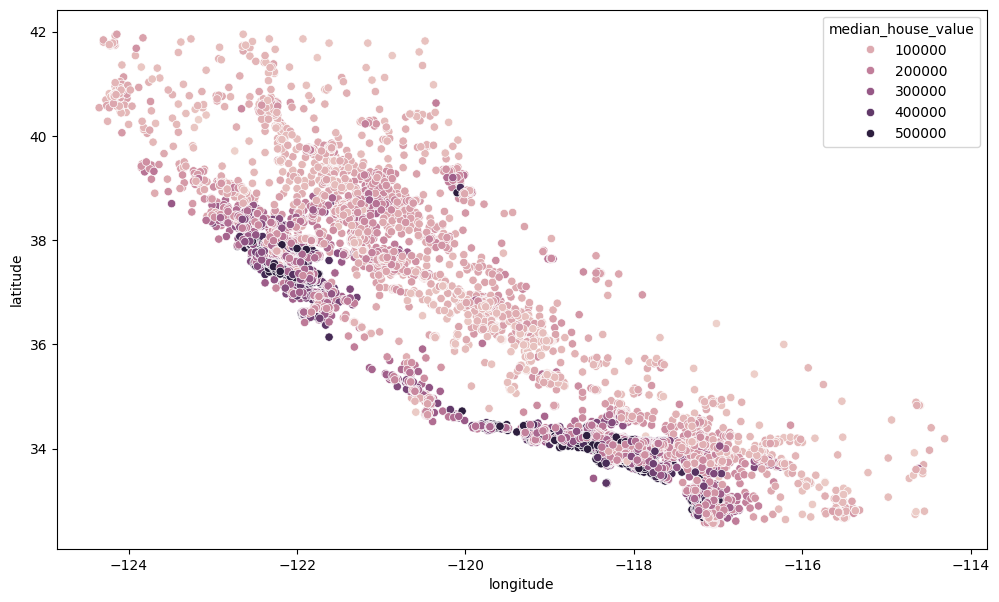

In [20]:
plt.figure(figsize=(12,7))

sns.scatterplot(data = train_data, x='longitude', y='latitude', hue='median_house_value')

<Axes: xlabel='longitude', ylabel='latitude'>

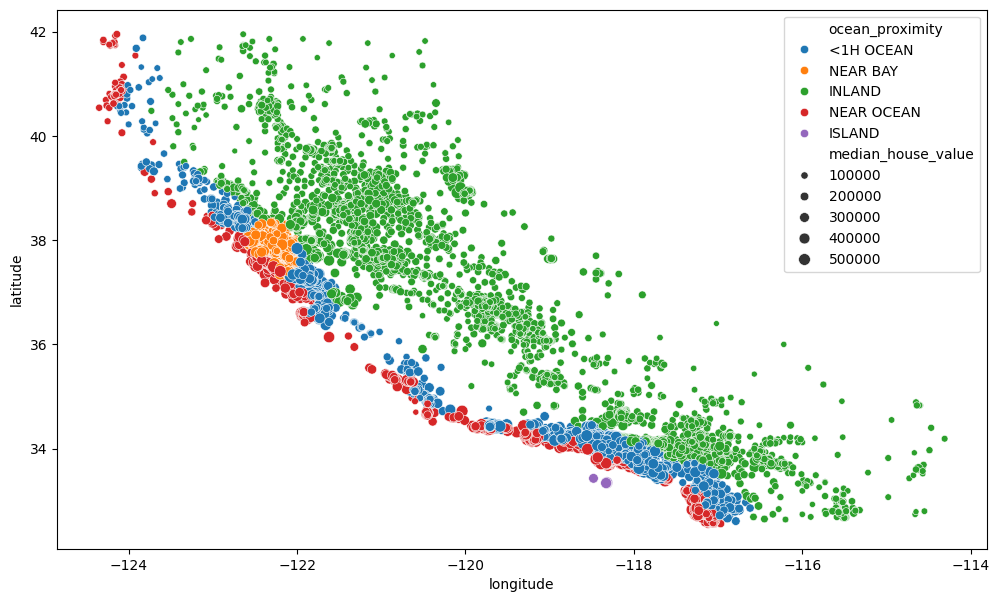

In [21]:
plt.figure(figsize=(12,7))

sns.scatterplot(data = train_data, x='longitude', y='latitude', hue='ocean_proximity', 
                size='median_house_value')

<Axes: xlabel='median_house_value', ylabel='median_income'>

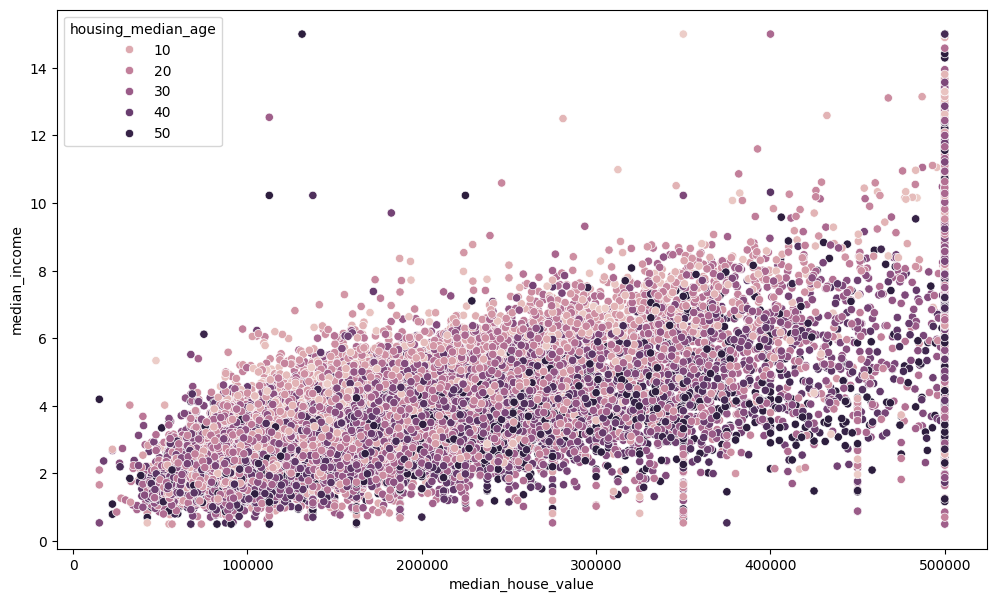

In [22]:
plt.figure(figsize=(12,7))

sns.scatterplot(data = train_data, x='median_house_value', y='median_income', hue='housing_median_age')

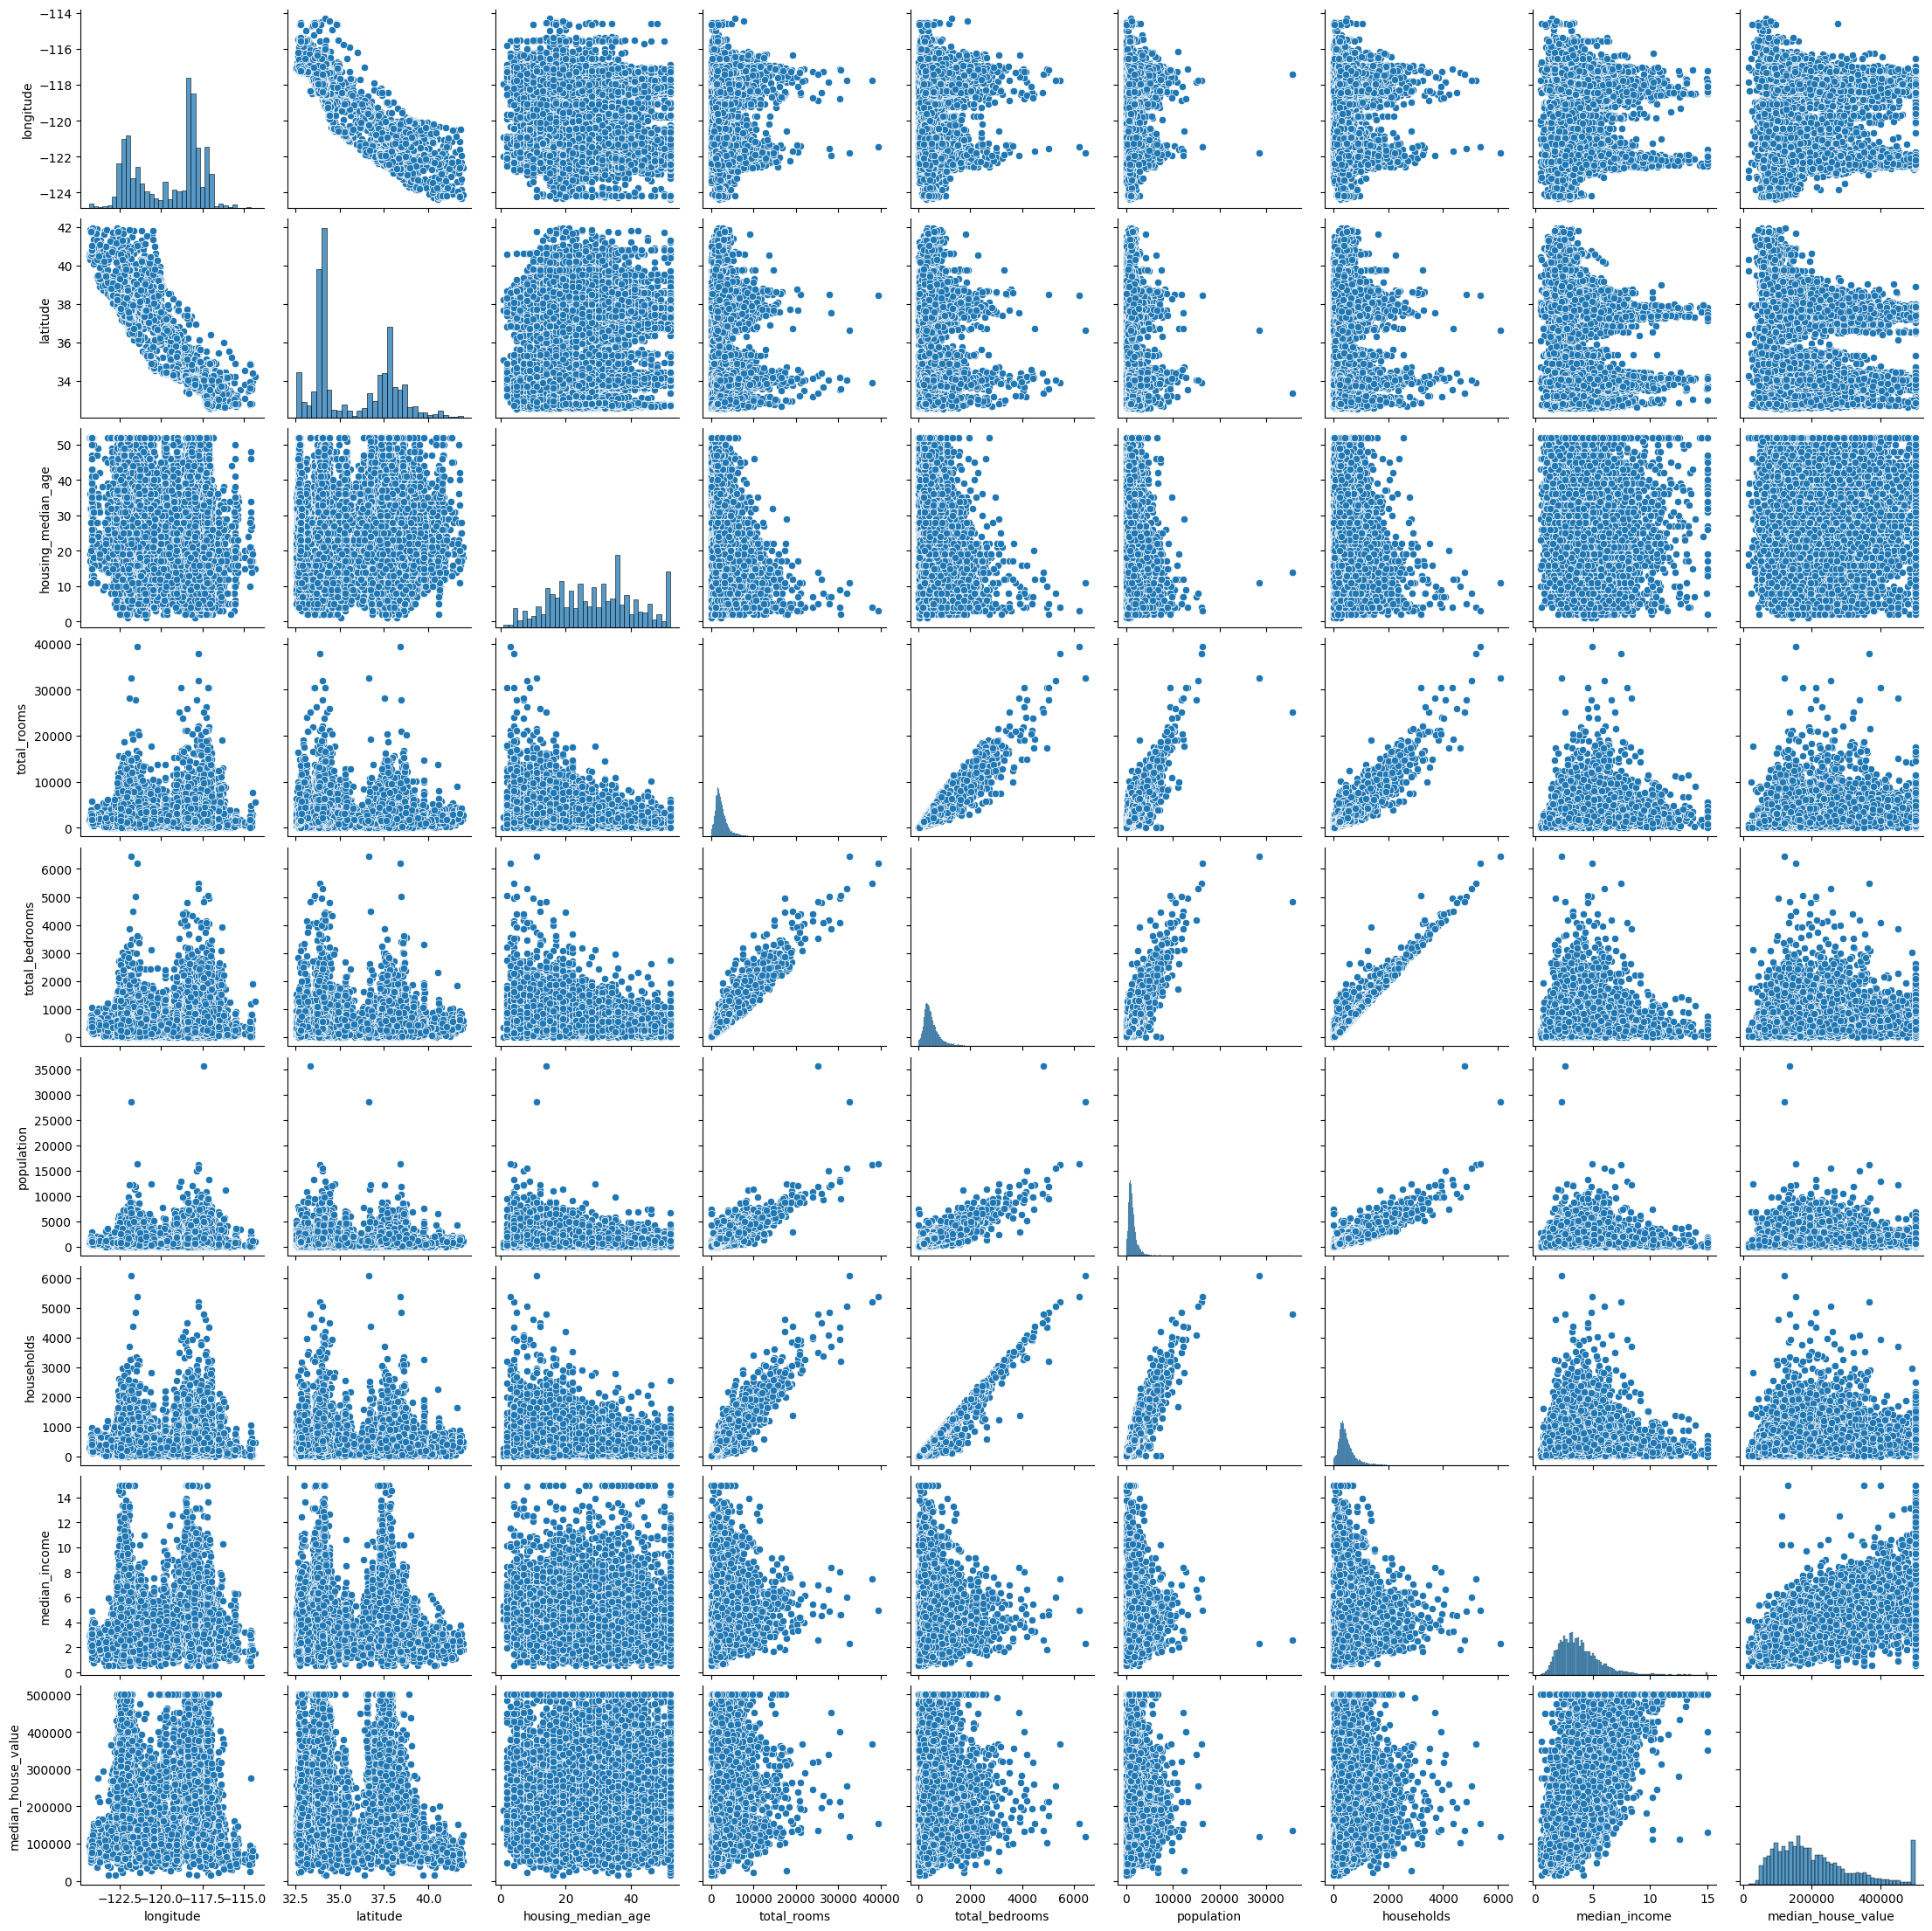

In [23]:
sns.pairplot(train_data)

In [24]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5564,-118.29,33.91,41.0,2475.0,532.0,1416.0,470.0,3.8372,156400.0,<1H OCEAN
16016,-122.46,37.73,52.0,3547.0,506.0,1276.0,491.0,8.0069,426800.0,NEAR BAY
17131,-122.15,37.46,30.0,4198.0,1244.0,2678.0,1147.0,3.6712,308600.0,NEAR BAY
11752,-121.21,38.76,16.0,1608.0,296.0,792.0,286.0,3.1583,239200.0,INLAND
2308,-119.75,36.83,15.0,2793.0,436.0,1411.0,441.0,4.9292,109400.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,<1H OCEAN
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,INLAND
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,<1H OCEAN
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,<1H OCEAN


In [25]:
training_input_data = train_data.drop('median_house_value', axis=1)
training_labels = train_data['median_house_value']

In [26]:
training_input_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
5564,-118.29,33.91,41.0,2475.0,532.0,1416.0,470.0,3.8372,<1H OCEAN
16016,-122.46,37.73,52.0,3547.0,506.0,1276.0,491.0,8.0069,NEAR BAY
17131,-122.15,37.46,30.0,4198.0,1244.0,2678.0,1147.0,3.6712,NEAR BAY
11752,-121.21,38.76,16.0,1608.0,296.0,792.0,286.0,3.1583,INLAND
2308,-119.75,36.83,15.0,2793.0,436.0,1411.0,441.0,4.9292,INLAND


In [27]:
training_labels.head(3)


5564     156400.0
16016    426800.0
17131    308600.0
Name: median_house_value, dtype: float64

In [28]:
from sklearn.impute import SimpleImputer
num_feats = training_input_data.drop('ocean_proximity', axis=1)


In [29]:
# Function creation for handling missing values 
def handle_missing_values(input_data):
  """
  Docstring 

  # This is a function to take numerical features...
  ...and impute the missing values
  # We are filling missing values with mean
  # fit_transform fit the imputer on input data and transform it immediately
  # You can use fit(input_data) and then transform(input_data) or
  # Or do it at once with fit.transform(input_data)
  # Imputer returns the imputed data as a NumPy array 
  # We will convert it back to Pandas dataframe

  """
  mean_imputer = SimpleImputer(strategy='mean')
  num_feats_imputed = mean_imputer.fit_transform(input_data)
  num_feats_imputed = pd.DataFrame(num_feats_imputed, 
                            columns=input_data.columns, index=input_data.index )


  return num_feats_imputed

In [30]:
num_feats_imputed = handle_missing_values(num_feats)
num_feats_imputed.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

### Encoding Categorical features

#### Mapping

In [31]:
training_input_data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8221
INLAND        5913
NEAR OCEAN    2366
NEAR BAY      2071
ISLAND           5
Name: count, dtype: int64

In [32]:
cat_feats = training_input_data['ocean_proximity']
cat_feats.value_counts()

ocean_proximity
<1H OCEAN     8221
INLAND        5913
NEAR OCEAN    2366
NEAR BAY      2071
ISLAND           5
Name: count, dtype: int64

In [33]:
# creation of feature mapping
feat_map = {
      '<1H OCEAN': 0,
      'INLAND': 1,
      'NEAR OCEAN': 2,
      'NEAR BAY': 3, 
      'ISLAND': 4
}

cat_feats_encoded = cat_feats.map(feat_map)
cat_feats_encoded.head()

5564     0
16016    3
17131    3
11752    1
2308     1
Name: ocean_proximity, dtype: int64

#### Ordinal Encoding

In [34]:
from sklearn.preprocessing import OrdinalEncoder

def ordinary_encoder(input_data):
  
  encoder = OrdinalEncoder()
  
  output = encoder.fit_transform(input_data)

  return output

In [35]:
cat_feats.shape

(18576,)

In [36]:
# cat_feats_enc = ordinary_encoder(cat_feats.to_frame())
# or 
cat_feats_enc = ordinary_encoder(cat_feats.values.reshape(-1,1))
cat_feats_enc

array([[0.],
       [3.],
       [3.],
       ...,
       [0.],
       [0.],
       [3.]], shape=(18576, 1))

#### One-hot Encoding

In [37]:
from sklearn.preprocessing import OneHotEncoder

def one_hot(input_data):

  one_hot_encoder = OneHotEncoder()
  output = one_hot_encoder.fit_transform(input_data)
  
  # The output of one hot encoder is a sparse matrix. 
  # It's best to convert it into numpy array 
  output = output.toarray()

  return output

In [38]:
cat_feats = training_input_data[['ocean_proximity']]

cat_feats_hot = one_hot(cat_feats)

cat_feats_hot

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(18576, 5))

### Scaling Numerical features

#### Normalization

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_scaled = scaler.fit_transform(num_feats)
num_scaled

array([[0.60358566, 0.14468085, 0.78431373, ..., 0.03960313, 0.07712547,
        0.23015545],
       [0.18824701, 0.55106383, 1.        , ..., 0.03567925, 0.08057885,
        0.517717  ],
       [0.21912351, 0.52234043, 0.56862745, ..., 0.07497407, 0.18845585,
        0.21870733],
       ...,
       [0.59462151, 0.15744681, 0.68627451, ..., 0.04913254, 0.08649893,
        0.16789424],
       [0.23804781, 0.53510638, 0.2745098 , ..., 0.04972112, 0.09176122,
        0.35994676],
       [0.19223108, 0.55531915, 1.        , ..., 0.07332044, 0.20407828,
        0.14314285]], shape=(18576, 8))

#### Standardization

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_scaled = scaler.fit_transform(num_feats)
num_scaled

array([[ 0.64130268, -0.80886286,  0.98351287, ..., -0.00969912,
        -0.07768305, -0.01883674],
       [-1.43975779,  0.9803686 ,  1.85679302, ..., -0.13251859,
        -0.02266257,  2.18523706],
       [-1.28505066,  0.8539046 ,  0.11023273, ...,  1.09743063,
         1.69607218, -0.10658316],
       ...,
       [ 0.5963877 , -0.75265664,  0.58656735, ...,  0.28857672,
         0.07165824, -0.4960504 ],
       [-1.19023016,  0.91011082, -1.08060383, ...,  0.30699964,
         0.15549896,  0.97597509],
       [-1.41979558,  0.99910401,  1.85679302, ...,  1.045671  ,
         1.94497432, -0.68576239]], shape=(18576, 8))

### Pipeline

In [57]:
from sklearn.pipeline import Pipeline

num_feats_pipe = Pipeline([
                  ('imputer', SimpleImputer(strategy='mean')), 
                  ('scaler', StandardScaler())         
            ])

num_feats_preprocessed = num_feats_pipe.fit_transform(num_feats)

In [58]:
num_feats_preprocessed

array([[ 0.64130268, -0.80886286,  0.98351287, ..., -0.00969912,
        -0.07768305, -0.01883674],
       [-1.43975779,  0.9803686 ,  1.85679302, ..., -0.13251859,
        -0.02266257,  2.18523706],
       [-1.28505066,  0.8539046 ,  0.11023273, ...,  1.09743063,
         1.69607218, -0.10658316],
       ...,
       [ 0.5963877 , -0.75265664,  0.58656735, ...,  0.28857672,
         0.07165824, -0.4960504 ],
       [-1.19023016,  0.91011082, -1.08060383, ...,  0.30699964,
         0.15549896,  0.97597509],
       [-1.41979558,  0.99910401,  1.85679302, ...,  1.045671  ,
         1.94497432, -0.68576239]], shape=(18576, 8))

In [59]:
num_feats_pipe.steps[0],num_feats_pipe.steps[1]

(('imputer', SimpleImputer()), ('scaler', StandardScaler()))

In [60]:
cat_feats_pipe = Pipeline([
     ('encoder', OneHotEncoder())                      
])

cat_feats_preprocessed = cat_feats_pipe.fit_transform(cat_feats)

In [61]:
cat_feats_preprocessed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18576 stored elements and shape (18576, 5)>

### ColumnTransformer

In [68]:
from sklearn.compose import ColumnTransformer

# The transformer requires lists of features

num_list = list(num_feats)
cat_list = list(cat_feats)

final_pipe = ColumnTransformer([
   ('num', num_feats_pipe, num_list),    
   ('cat', cat_feats_pipe, cat_list)                        

])

training_data_preprocessed = final_pipe.fit_transform(training_input_data)

In [69]:
training_data_preprocessed

array([[ 0.64130268, -0.80886286,  0.98351287, ...,  0.        ,
         0.        ,  0.        ],
       [-1.43975779,  0.9803686 ,  1.85679302, ...,  0.        ,
         1.        ,  0.        ],
       [-1.28505066,  0.8539046 ,  0.11023273, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.5963877 , -0.75265664,  0.58656735, ...,  0.        ,
         0.        ,  0.        ],
       [-1.19023016,  0.91011082, -1.08060383, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41979558,  0.99910401,  1.85679302, ...,  0.        ,
         1.        ,  0.        ]], shape=(18576, 13))

In [70]:
type(training_data_preprocessed)

numpy.ndarray

### Training a model

In [71]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

In [72]:
reg_model.fit(training_data_preprocessed, training_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
reg_model.coef_, reg_model.intercept_

(array([-53925.31747515, -54522.77733925,  13826.99450252, -13946.79441338,
         44307.09962425, -43347.62104419,  17795.50516104,  74983.76343333,
        -22477.02920224, -61623.49458973, 130042.79608098, -27527.78549267,
        -18414.48679634]),
 np.float64(241804.2395626453))

### Model Evaluation 

In [89]:
from sklearn.metrics import mean_squared_error

predictions = reg_model.predict(training_data_preprocessed)

In [92]:
mse = mean_squared_error(training_labels, predictions)

rmse = np.sqrt(mse)
rmse 

np.float64(68353.23558707176)

In [93]:
train_data.describe().median_house_value['mean']

np.float64(206861.73923341947)

## The mean price of the house from the whole dataset is $206,881. With the RMSE of $68,438, that means we are off $138,443 the predictions.

### Model evaluation with cross validation

In [87]:
from sklearn.model_selection import cross_val_score

scoring = 'neg_root_mean_squared_error' 

scores = cross_val_score(reg_model, training_data_preprocessed, training_labels, scoring=scoring, cv=10)

In [88]:
scores=-scores
scores.mean()

np.float64(68469.40333432532)

In [94]:
from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(reg_model, training_data_preprocessed, training_labels, cv=10)

In [95]:
mse_cross_val = mean_squared_error(training_labels, predictions)
rmse_cross_val = np.sqrt(mse_cross_val)
rmse_cross_val 

np.float64(68512.41021213336)

#### Evaluate the model on test set

In [96]:
test_input_data = test_data.drop('median_house_value', axis=1)
test_labels = test_data['median_house_value']


test_preprocessed = final_pipe.transform(test_input_data)

In [97]:
test_pred = reg_model.predict(test_preprocessed)
test_mse = mean_squared_error(test_labels,test_pred)

test_rmse = np.sqrt(test_mse)
test_rmse

np.float64(72353.89644518217)